<a href="https://colab.research.google.com/github/Vatsal-Savani-006/Fake-News-Detection-System-Mini-Project-Sem-6/blob/main/LSTM_MODEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#LSTM Model Training

##Import the Important Libraries

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

##Load ISOT Dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fake-and-real-news-dataset' dataset.
Path to dataset files: /kaggle/input/fake-and-real-news-dataset


In [ ]:
fake_df = pd.read_csv(path + "/Fake.csv")
true_df = pd.read_csv(path + "/True.csv")

# Add labels
fake_df["label"] = 0  # Fake
true_df["label"] = 1  # Real

# Combine datasets
df = pd.concat([fake_df, true_df], axis=0)

# Shuffle
df = df.sample(frac=1).reset_index(drop=True)

df.head()

,title,text,subject,date,label
0,Food and drug chief Gottlieb skirts health sec...,(Reuters) - U.S. Food and Drug Administration ...,politicsNews,"October 10, 2017",1
1,Trump on Twitter (May 15) - National Peace Off...,The following statements were posted to the ve...,politicsNews,"May 16, 2017",1
2,"Trump, Japan's Abe toast 'bromance' as two-day...",TOKYO (Reuters) - Every American president has...,politicsNews,"November 6, 2017",1
3,Fox News Host Leaks That Spicer Is Getting Fi...,Already demonstrating her inability to keep he...,News,"May 16, 2017",0
4,UPDATE: WIKILEAKS CLINTON Document Dump Back On!,Hillary Clinton strategist Bob Beckel called f...,politics,"Oct 2, 2016",0


##Data Preprocessing

In [ ]:
df["content"] = df["title"] + " " + df["text"]

# Keep only necessary columns
df = df[["content", "label"]]

# Remove nulls
df.dropna(inplace=True)

##Train-Test-Split

In [ ]:
X = df["content"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##Tokenization

In [ ]:
vocab_size = 10000
max_len = 300

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

##Build LSTM Model

In [ ]:
model = Sequential()

model.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len))

model.add(LSTM(64, return_sequences=False))

model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

##Train Model

In [ ]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
506/506 ━━━━━━━━━━━━━━━━━━━━ 187s 365ms/step - accuracy: 0.8303 - loss: 0.3332 - val_accuracy: 0.9688 - val_loss: 0.1133
Epoch 2/5
506/506 ━━━━━━━━━━━━━━━━━━━━ 190s 342ms/step - accuracy: 0.9765 - loss: 0.0951 - val_accuracy: 0.8909 - val_loss: 0.3311
Epoch 3/5
506/506 ━━━━━━━━━━━━━━━━━━━━ 172s 339ms/step - accuracy: 0.9596 - loss: 0.1117 - val_accuracy: 0.9869 - val_loss: 0.0550
Epoch 4/5
506/506 ━━━━━━━━━━━━━━━━━━━━ 173s 341ms/step - accuracy: 0.9904 - loss: 0.0423 - val_accuracy: 0.9819 - val_loss: 0.0706
Epoch 5/5
506/506 ━━━━━━━━━━━━━━━━━━━━ 171s 339ms/step - accuracy: 0.9931 - loss: 0.0306 - val_accuracy: 0.9891 - val_loss: 0.0471


##Evaluate Model

In [ ]:
y_pred = model.predict(X_test_pad)

# Convert probabilities to 0/1
y_pred = (y_pred > 0.5).astype(int)


print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

281/281 ━━━━━━━━━━━━━━━━━━━━ 13s 45ms/step
Accuracy: 0.9867483296213808
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4688
           1       0.98      0.99      0.99      4292

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



##Confusion Matrix

[[4619   69]
 [  50 4242]]


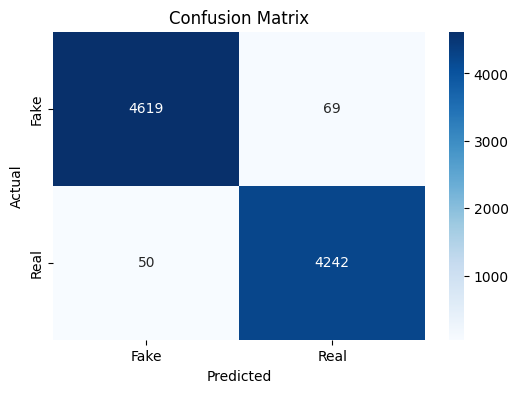

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
print(cm)
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
import pickle
with open('LSTM_Model.pkl', 'wb') as f:
  pickle.dump(model, f)
with open('LSTM_Tokenizer.pkl', 'wb') as f:
  pickle.dump(tokenizer, f)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Predictions
y_pred = model.predict(X_test_pad)
y_pred = (y_pred > 0.5).astype(int)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print all
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

# Detailed report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

281/281 ━━━━━━━━━━━━━━━━━━━━ 18s 62ms/step
Accuracy : 0.9867483296213808
Precision: 0.9839944328462074
Recall   : 0.9883504193849021
F1 Score : 0.9861676159479251

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4688
           1       0.98      0.99      0.99      4292

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



##Test on Custom News

In [ ]:
def predict_news(text):
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=max_len, padding='post')

    pred = model.predict(padded)[0][0]

    if pred > 0.5:
        return "REAL NEWS"
    else:
        return "FAKE NEWS"

#Testing on Fake and Real News Dataset

In [ ]:
import kagglehub

path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")
print("Dataset path:", path)

Using Colab cache for faster access to the 'fake-and-real-news-dataset' dataset.
Dataset path: /kaggle/input/fake-and-real-news-dataset


In [ ]:
import os
import pandas as pd

print(os.listdir(path))

fake_df = pd.read_csv(os.path.join(path, "Fake.csv"))
true_df = pd.read_csv(os.path.join(path, "True.csv"))

['True.csv', 'Fake.csv']


In [ ]:
fake_df["label"] = 0   # Fake
true_df["label"] = 1   # Real

df_new = pd.concat([fake_df, true_df], axis=0)
df_new = df_new.sample(frac=1).reset_index(drop=True)

In [ ]:
df_new["content"] = df_new["title"] + " " + df_new["text"]

df_new = df_new[["content", "label"]]
df_new.dropna(inplace=True)

In [ ]:
X_new = df_new["content"]
y_new = df_new["label"]

X_new_seq = tokenizer.texts_to_sequences(X_new)
X_new_pad = pad_sequences(X_new_seq, maxlen=max_len, padding='post')

In [ ]:
y_new_pred = model.predict(X_new_pad)
y_new_pred = (y_new_pred > 0.5).astype(int)

1404/1404 ━━━━━━━━━━━━━━━━━━━━ 66s 47ms/step


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy on new dataset:", accuracy_score(y_new, y_new_pred))

print("\nClassification Report:\n")
print(classification_report(y_new, y_new_pred))

Accuracy on new dataset: 0.9942759142946234

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     23481
           1       0.99      1.00      0.99     21417

    accuracy                           0.99     44898
   macro avg       0.99      0.99      0.99     44898
weighted avg       0.99      0.99      0.99     44898



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

accuracy = accuracy_score(y_new, y_new_pred)
precision = precision_score(y_new, y_new_pred)
recall = recall_score(y_new, y_new_pred)
f1 = f1_score(y_new, y_new_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nDetailed Classification Report:\n")
print(classification_report(y_new, y_new_pred, target_names=["Fake", "Real"]))

Accuracy : 0.9942759142946234
Precision: 0.9929183749534104
Recall   : 0.995097352570388
F1 Score : 0.9940066696205779

Detailed Classification Report:

              precision    recall  f1-score   support

        Fake       1.00      0.99      0.99     23481
        Real       0.99      1.00      0.99     21417

    accuracy                           0.99     44898
   macro avg       0.99      0.99      0.99     44898
weighted avg       0.99      0.99      0.99     44898



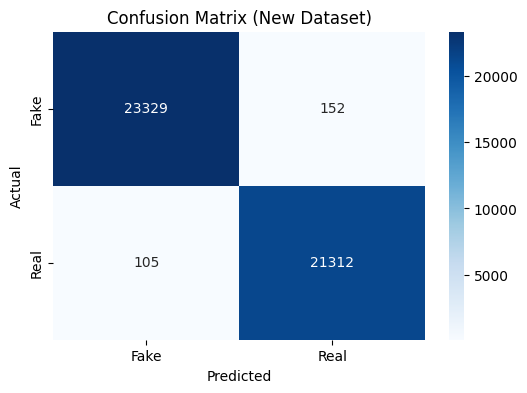

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_new, y_new_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (New Dataset)")
plt.show()

#Testing on LIAR Dataset

In [ ]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("doanquanvietnamca/liar-dataset")

print("Dataset path:", path)

Using Colab cache for faster access to the 'liar-dataset' dataset.
Dataset path: /kaggle/input/liar-dataset


In [ ]:
import os
import pandas as pd

# Check files
print(os.listdir(path))

# Load test data
test_path = os.path.join(path, "test.tsv")

liar_df = pd.read_csv(test_path, sep='\t', header=None)

['test.tsv', 'README', 'train.tsv', 'valid.tsv']


In [ ]:
liar_df = liar_df[[0, 2]]
liar_df.columns = ["label", "content"]

In [ ]:
def convert_label(label):
    if label in ["true", "mostly-true"]:
        return 1   # REAL
    else:
        return 0   # FAKE

liar_df["label"] = liar_df["label"].apply(convert_label)

In [ ]:
liar_df.dropna(inplace=True)
liar_df.head()

,label,content
0,0,Building a wall on the U.S.-Mexico border will...
1,0,Wisconsin is on pace to double the number of l...
2,0,Says John McCain has done nothing to help the ...
3,0,Suzanne Bonamici supports a plan that will cut...
4,0,When asked by a reporter whether hes at the ce...


In [ ]:
X_liar = liar_df["content"]
y_liar = liar_df["label"]

X_liar_seq = tokenizer.texts_to_sequences(X_liar)
X_liar_pad = pad_sequences(X_liar_seq, maxlen=max_len, padding='post')

In [ ]:
y_liar_pred = model.predict(X_liar_pad)
y_liar_pred = (y_liar_pred > 0.5).astype(int)

40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy on LIAR:", accuracy_score(y_liar, y_liar_pred))

print("\nClassification Report:\n")
print(classification_report(y_liar, y_liar_pred))

Accuracy on LIAR: 0.5114443567482242

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.51      0.68      1267
           1       0.00      0.00      0.00         0

    accuracy                           0.51      1267
   macro avg       0.50      0.26      0.34      1267
weighted avg       1.00      0.51      0.68      1267



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Accuracy
accuracy = accuracy_score(y_liar, y_liar_pred)

# Precision, Recall, F1
precision = precision_score(y_liar, y_liar_pred)
recall = recall_score(y_liar, y_liar_pred)
f1 = f1_score(y_liar, y_liar_pred)

# Print results
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

# Detailed report
print("\nClassification Report:\n")
print(classification_report(y_liar, y_liar_pred, target_names=["Fake", "Real"]))

Accuracy : 0.5114443567482242
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0

Classification Report:

              precision    recall  f1-score   support

        Fake       1.00      0.51      0.68      1267
        Real       0.00      0.00      0.00         0

    accuracy                           0.51      1267
   macro avg       0.50      0.26      0.34      1267
weighted avg       1.00      0.51      0.68      1267



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: 

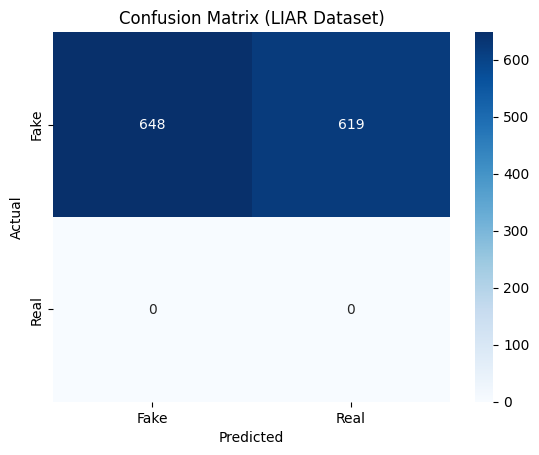

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_liar, y_liar_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (LIAR Dataset)")
plt.show()